#### Finite Nuclei

Define any EoS model as a Python list and run `./ns ModelName params A N`.

In [1]:
import subprocess, re, os, math, pandas as pd, matplotlib.pyplot as plt, numpy as np

SOLVER_DIR = os.path.dirname(os.path.abspath('FiniteNuclei.ipynb'))
NS = os.path.join(SOLVER_DIR, 'ns')

In [2]:
# Order: g2_s, g2_v, g2_rho, alpha, m_s(MeV), m_v(MeV), m_rho(MeV), kappa, lambda, zeta, Lambda

LINEAR    = [109.63, 190.43, 65.226, math.pi*4/137.036, 520.0, 782.5, 770.0, 0.0, 0.0, 0.0, 0.0]
NL3       = [104.3871, 165.5854, 79.60, math.pi*4/137.036, 508.194, 782.501, 763.0, 3.85990, -0.015905, 0.0, 0.0]
FSUGOLD   = [108.0943, 183.7893, 80.4656, math.pi*4/137.036, 497.479, 782.50, 763.0, 3.0029, -0.000533, 0.0256, 0.0]
FSUGOLD2  = [108.0943, 183.7893, 80.4656, math.pi*4/137.036, 497.479, 782.50, 763.0, 3.0029, -0.000533, 0.0256, 0.000823]
FSUGARNET = [110.349189, 187.694677, 192.927428, math.pi*4/137.036, 496.939473, 782.50, 763.0, 3.260179, -0.003551, 0.0235, 0.043377]


In [3]:
def run_rmf(model_name, params, A, N):
    assert len(params) == 11, 'Expected 11 model parameters'
    cmd = [NS, model_name] + [str(p) for p in params] + [str(A), str(N)]
    res = subprocess.run(cmd, capture_output=True, text=True, cwd=SOLVER_DIR)
    if res.returncode != 0:
        raise RuntimeError(res.stderr)
    be = None
    for line in res.stdout.splitlines():
        m = re.search(r'Binding energy per nucleon\s*=\s*([\d.eE+\-]+)', line)
        if m: be = float(m.group(1))
    if be is None:
        raise ValueError('Could not parse BE/A.\n' + res.stdout)

    rms_p = rms_n = None
    gsp_file = os.path.join(SOLVER_DIR, 'NLRMF', f'STATES{A}{model_name}.txt')
    if os.path.exists(gsp_file):
        with open(gsp_file) as f:
            for line in f:
                mp = re.search(r'RMS radii of proton:\s*([\d.eE+\-]+)', line)
                mn = re.search(r'RMS radii of neutron:\s*([\d.eE+\-]+)', line)
                if mp: rms_p = float(mp.group(1))
                if mn: rms_n = float(mn.group(1))

    return {'model': model_name, 'A': A, 'Z': A - N, 'N': N,
            'BE': be, 'rms_p': rms_p, 'rms_n': rms_n,
            'skin': round(rms_n - rms_p, 5) if (rms_p and rms_n) else None}

In [7]:
A, N = 208, 126
out = run_rmf('FSUGARNET', FSUGARNET, A, N)
print(f"Model        : {out['model']}")
print(f"Nucleus      : A={out['A']}, Z={out['Z']}, N={out['N']}")
print(f"B.E./A       : {out['BE']:.5f} MeV")
# print(f"RMS proton r : {out['rms_p']} fm")
# print(f"RMS neutron r: {out['rms_n']} fm")
# print(f"Neutron skin : {out['skin']} fm")

Model        : FSUGARNET
Nucleus      : A=208, Z=82, N=126
B.E./A       : -7.90457 MeV


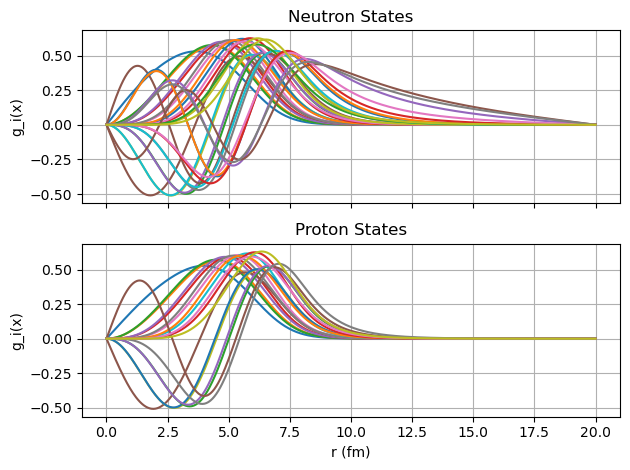

In [8]:
with open("NLRMF/WaveFunction208FSUGARNET.txt", "r") as file:
    lines = file.readlines()

sep_index = next(i for i, line in enumerate(lines) if line.startswith("#"))

neutron_lines = lines[1:sep_index]
proton_lines = lines[sep_index + 2:]

neutron_data = np.loadtxt(neutron_lines)
proton_data = np.loadtxt(proton_lines)

r_n = neutron_data[:, 0]
g_n = neutron_data[:, 1::2]

r_p = proton_data[:, 0]
g_p = proton_data[:, 1::2]

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

for i in range(g_n.shape[1]):
    ax1.plot(r_n, g_n[:, i], label=f"g{i+1}")
ax1.set_title("Neutron States")
ax1.set_ylabel("g_i(x)")
ax1.grid(True)
# ax1.legend()

for i in range(g_p.shape[1]):
    ax2.plot(r_p, g_p[:, i], label=f"g{i+1}")
ax2.set_title("Proton States")
ax2.set_xlabel("r (fm)")
ax2.set_ylabel("g_i(x)")
ax2.grid(True)
# ax2.legend()

plt.tight_layout()
plt.show()